# 贝叶斯参数估计的简单示例
我们将展示如何实现 MCMC 的一个简单示例：判断一枚硬币是否公平


In [1]:
%matplotlib inline
from matplotlib import pyplot as plt
from scipy import stats
import numpy as np

Configuration parameters

In [2]:
actual_theta = 0.76
n_samples = 4

## 问题陈述

我们的目标是利用贝叶斯统计方法，通过实验证据来判断一枚硬币是否公平。

贝叶斯方法的核心在于：先对系统有一个先验信念，然后根据系统的表现证据更新这一信念，形成新的“后验”信念。

我们将这些信念建模为概率分布。例如，在抛硬币的例子中，我们可以这样建模：

$P(H) = \theta$

其中，我们用变量 $\theta$ 表示硬币的公平程度。

## 先验分布

一开始，我们对硬币的公平性不做任何假设，认为 $\theta$ 可以取 0 到 1 之间的任意值。

我们用均匀概率分布来表达这一先验信念，即所谓的弥散先验：$P(\theta) = U(0, 1)$


In [3]:
prior = stats.uniform(0, 1)

Text(0.5, 1.0, 'Prior Distribution')

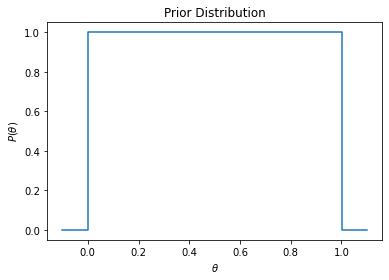

In [4]:
fig, ax = plt.subplots()

x = np.linspace(-0.1, 1.1, 128)
ax.step(x, prior.pdf(x), where='mid')

ax.set_xlabel('$\\theta$')
ax.set_ylabel('$P(\\theta)$')
ax.set_title('Prior Distribution')

## 贝叶斯法则简介
贝叶斯法则允许我们在收集到更多关于问题的数据后，更新先验分布，从而形成一个“后验”分布，该分布定义了我们在收集数据后对参数的信念。

用数学语言表达，我们可以将贝叶斯法则写为

$P(\theta|D, M) = \frac{P(D|\theta,M)P(\theta|M)}{P(D|M)}$

其中
- $P(\theta|D, M)$ 是我们的后验分布——一个函数，用于捕捉在给定观测数据（$D$）和所选模型形式（$M$）的情况下参数 $\theta$ 的概率。
- $P(D|\theta,M)$ 是我们的似然函数，即在给定模型形式和参数选择的情况下观测到数据的概率。
- $P(D|M)$ 是证据，即在给定所选模型的情况下观测到数据的总概率。
- $P(\theta|M)$ 是我们的先验信念——即在收集任何数据之前我们对参数的假设。

## 进行一些实验
现在我们已经设定好了问题，让我们多次抛掷一枚硬币。


In [5]:
coin = stats.bernoulli(actual_theta)  # Make an engine that flips a heads (1), 60% of the time

In [6]:
samples = coin.rvs(n_samples)
print(f'Flipped the coin {len(samples)} times')

Flipped the coin 4 times


In [7]:
print(f'The coin flipped heads {samples.mean()*100:.1f}% of the time. So, it seems biased but we can be more sure')

The coin flipped heads 75.0% of the time. So, it seems biased but we can be more sure


## 从后验分布中采样
许多你想进行的分析都涉及计算后验分布的性质（也就是给定数据后模型参数的分布）。

解析地求解这个分布（即给出概率随参数变化的函数）几乎是不可能的。但是，有一些技术可以在不知道其真实形状的情况下从这个分布中抽取样本，比如[马尔可夫链蒙特卡洛（MCMC）方法](https://www.nature.com/articles/s43586-020-00001-2/tables/1)。

这里，我们实现一个简单的方法——["Metropolis-Hasting Monte Carlo"](https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm)。

该算法如下：
1. 从先验分布中随机选择一个点 $\theta$ 作为起点
2. 通过给 $\theta$ 加上随机值生成一个新点 $\theta_{new}$
3. 计算 $\theta_{new}$ 与 $\theta$ 的相对后验概率
   $r = \frac{P(\theta_{new}|D,M)}{P(\theta|D,M)}=\frac{P(D|\theta_{new},M)P(\theta_{new}|M)}{P(D|\theta,M)P(\theta|M)}$
   
   推导的第二步应用了贝叶斯定理。注意，证据项 $P(D|M)$ 被约掉了
4. 从 0 到 1 的均匀分布中随机抽取一个数 $\beta$
5. 如果 $\beta > min(1, r)$，则令 $\theta = \theta_{new}$
6. 回到第 2 步重复

由于“细致平衡”原理，$\theta$ 的分布将等同于后验分布。

接下来，我们展示如何实现该算法

### 第一步：生成新点
我们定义一个函数，根据前一个参数生成新参数。对该函数几乎没有限制，只需满足对称性即可。


In [8]:
def perturb(th):
    return th + np.random.uniform(-0.2, 0.2)
print(f'New random point given 0.5: {perturb(0.5):.2f}')

New random point given 0.5: 0.63


### 第二步：计算后验概率
后验概率包含两项：给定数据下的参数似然（$P(D|\theta,M)$）以及先验分布（$P(\theta,M)$）。

先验部分很简单：我们规定所有在 -0.5 到 0.5 之间的点概率均等。

似然部分则复杂一些，需要考虑模型形式——伯努利分布。

详见 [MathWorld](https://mathworld.wolfram.com/BernoulliDistribution.html)。简而言之，在 $N$ 次抛掷中观测到 $n$ 次正面的概率，可表示为参数 $\theta$ 的函数：

$P(n|\theta,N) = {N \choose n}\theta^n(1-\theta)^{N-n}$

于是，我们可以写出概率比：

$r = \frac{P(D|\theta_{new},M)P(\theta_{new}|M)}{P(D|\theta,M)P(\theta|M)} = \frac{\theta_{new}^n(1-\theta_{new})^{N-n}}{\theta^n(1-\theta)^{N-n}}$


In [9]:
def relative_prob(a, b, n, N):
    """
    Args:
        a - New point
        b - Old point (must be within -0.5 and 0.5)
    Returns:
        Relative probability of a and b
    """
    if a < 0 or a > 1:
        return 0
    return (a ** n) * (1 - a) ** (N - n) / (b ** n * (1 - b) ** (N - n))

In [10]:
relative_prob(0.55, 0.6, samples.sum(), len(samples))

0.8665364583333336

### 步骤 3：串联起来
编写一个函数，用于将 MCMC 循环运行指定次数。


In [11]:
def run_mcmc(n_steps):
    """Run MCMC
    
    Args:
        n_steps - Number of steps to run
    """
    
    # Draw a point from the prior distribution
    th = prior.rvs()
    
    # Loop to create new samples
    output = np.zeros(n_steps)
    for i in range(n_steps):
        # Generate a new point
        th_new = perturb(th)
        
        # Get the relative probability
        r = relative_prob(th_new, th, samples.sum(), len(samples))
        
        # Determine if we select the new point
        if np.random.random() < r:
            th = th_new
        
        # Store the point
        output[i] = th
    return output

## 执行 MCMC 采样
我们将运行大量样本以生成后验分布的统计信息


In [12]:
post_samples = run_mcmc(32768)

Text(0, 0.5, '$P(\\theta)$')

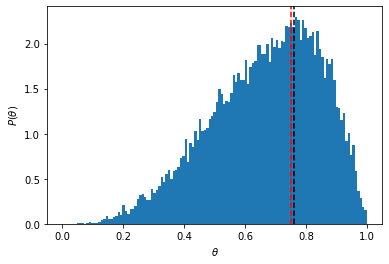

In [13]:
fig, ax = plt.subplots()

ax.hist(post_samples, bins=np.linspace(0, 1, 128), density=True)

# Plot the actual and the mean
ax.set_ylim(ax.get_ylim())
ax.plot([actual_theta]*2, ax.get_ylim(), 'k--')
ax.plot([samples.mean()]*2, ax.get_ylim(), 'r--')

ax.set_xlabel('$\\theta$')
ax.set_ylabel('$P(\\theta)$')